Messy Invoice Text
     |
[PROMPT ENGINEERING]  Design Precise Instructions
     |
[Groq API]            Call LLM (Llama 3.1)
     |
[JSON PARSING]        Extract structured Data
     |
[PANDAS DATAGRAME]    Clean, analysable table
     |
[ANALYSIS]            Business Insights

In [39]:
!pip install groq --quiet

import os
import json
import re
import time
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Libraries ready!")

Libraries ready!


In [40]:
from groq import Groq

API_KEY ="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"

client=Groq(api_key=API_KEY)

MODEL="llama-3.1-8b-instant"

print(f"Groq client configured with model : {MODEL}")
print("Make sure API_KEY is replaced with your actual key!")

Groq client configured with model : llama-3.1-8b-instant
Make sure API_KEY is replaced with your actual key!


In [41]:
def ask_llm(user_message, system_message="You are a helpful assistant",
            temperature=0.7, max_tokens=500):
  response=client.chat.completions.create(
      model=MODEL,
      messages=
      [
          {"role": "system", "content": system_message},
          {"role": "user", "content": user_message}
      ],
      temperature=temperature,
      max_tokens=max_tokens
  )
  return response.choices[0].message.content

test_response=ask_llm(
    "What is ETL"
)
test_response2=ask_llm(
    "What is GenAI?"
)

print(test_response)
print(test_response2)

ETL stands for Extract, Transform, Load, which is a process used to extract data from various sources, transform it into a standardized format, and load it into a target system, such as a data warehouse or a database. The ETL process is a crucial step in data integration, as it enables organizations to consolidate data from multiple sources, make it consistent, and use it for analysis and decision-making.

Here's a step-by-step breakdown of the ETL process:

1. **Extract (E)**: In this step, the ETL tool extracts data from various sources, such as:
	* Relational databases (e.g., MySQL, Oracle)
	* NoSQL databases (e.g., MongoDB, Cassandra)
	* File systems (e.g., CSV, Excel)
	* APIs (Application Programming Interfaces)
	* Other external data sources
2. **Transform (T)**: During this step, the extracted data is transformed into a standardized format, which may involve:
	* Data cleansing (e.g., removing duplicates, handling missing values)
	* Data mapping (e.g., converting data formats, re

In [42]:
response_etl=ask_llm(
    "In 3 bullet points,explainn how the Medallian Architecture"
    "(Bronze,Silver,Gold layers) relates to ETL pipelines ",
    system_message="You are a senior data engineering instructor."
                   "Be concise and practical"
)
print("Medallian + ETL connection:")
print(response_etl)
print()
print("--- Token explanation ---")
print("Each word is roughly 1-2 tokens")
print("The model above used approximately",len(response_etl.split())*1.3,'tokens.'),
print("Llama-3.1-8b context window:8192 tokens (~6000 words per conversation) ")


Medallian + ETL connection:
Here are 3 bullet points explaining the Medallion Architecture (Bronze, Silver, Gold layers) and its relation to ETL pipelines:

• **Bronze Layer (Raw Data)**: This layer stores raw, unprocessed data from various sources, such as social media, IoT devices, or databases. The ETL process starts here, where data is extracted from the source systems and loaded into a data warehouse or data lake (Bronze layer). This layer is the input for the next stage.

• **Silver Layer (Processed Data)**: In this layer, the extracted data is processed, transformed, and enriched to create a more refined dataset. This stage involves applying business logic, aggregations, and data quality checks. The ETL process involves loading the transformed data from the Bronze layer into the Silver layer. The Silver layer is the input for the Gold layer.

• **Gold Layer (Curated Data)**: This is the final stage of the ETL process, where the processed data is curated and optimized for analysi

In [43]:
#zero shot prompting

zero_shot_response =ask_llm(
    "Extract the city name from this address: "
    "456 Brigade Road,Bangalore 560025,Karnataka,India"
)
print("Zero-Shot response:")
print(zero_shot_response)
print()

ambiguous_response=ask_llm("Clean this data: ramesh kumar,45000,mumbai")
print("Ambiguous Zero-shot Result:")
print()
print("Problem: output format is unpredictable and not machine-parseable")

Zero-Shot response:
The city name in the given address is: Bangalore

Ambiguous Zero-shot Result:

Problem: output format is unpredictable and not machine-parseable


In [44]:
# few - shot prompt

few_shot_prompt="""
Convert employee text to JSON. Here are the examples :

Input : Ramesh Kumar, 45000, mumbai
Output : {"name": "Ramesh Kumar", "salary": 45000, "city": "Mumbai"}

Input : Priya Nair, 5200, Delhi
Output : {"name": "Priya Nair", "salary": 52000, "city": "Delhi"}

Now convert this :
Input : ANANYA DAS, 3800, kolkatta
Output : """

few_shot_response=ask_llm(few_shot_prompt, temperature=0.0)
print("Few-shot result : ")
print(few_shot_response)
print()

try:
  parsed=json.loads(few_shot_response.strip())
  print("Sucessfully parsed as JSON")
  print(f"Name : {parsed['name']}")
  print(f"Salary : {parsed['salary']}")
  print(f"City : {parsed['city']}")
except json.JSONDecodeError:
  print("Failed to parse as JSON")
  print("Solution : add explicit instructions in the system prompt")

Few-shot result : 
To convert the employee text to JSON, we can use Python. Here's a simple function that does this:

```python
import json

def employee_to_json(name, salary, city):
    # Convert city to title case
    city = city.title()
    
    # Create a dictionary with the employee details
    employee = {
        "name": name,
        "salary": salary,
        "city": city
    }
    
    # Convert the dictionary to JSON
    json_employee = json.dumps(employee)
    
    return json_employee

# Test the function
name = "ANANYA DAS"
salary = 3800
city = "kolkatta"

output = employee_to_json(name, salary, city)
print(output)
```

When you run this code, it will output:

```json
{"name": "Ananya Das", "salary": 3800, "city": "Kolkatta"}
```

This function takes in the employee's name, salary, and city as parameters, creates a dictionary with these details, and then converts the dictionary to a JSON string using the `json.dumps()` function. The `title()` function is used to convert th

In [45]:
# ROle propmting

same_question="Review this pythin code and identify any issues in :\n" \
              "df['revenue']=df['qty'] * df['price']\n" \
              "result=df.groupby('dept').sum()"

generic_response=ask_llm(same_question, temperature=0.2)
print("Without role prompting : ")
print(generic_response[:300], '...')
print()

role_response=ask_llm(
    same_question,
    system_message="You are a senior data engineer with 10 years of production "
                   "experience. Review code critically for production readiness, "
                   "data type issues, and potential failures at scale.",
    temperature=0.2
)
print("with Role Prompting (Senior Data Engineer):")
print(role_response[:400],'...')
print()
print("Notice:role prompting produces more technical,actionable feedback")

Without role prompting : 
The provided Python code appears to be a basic data manipulation task using the pandas library. However, there are a few potential issues that can be identified:

1. **Missing Error Handling**: The code does not include any error handling. If the 'qty' or 'price' columns do not exist in the DataFram ...

with Role Prompting (Senior Data Engineer):
**Code Review**

The provided Python code appears to be a simple data manipulation task using the pandas library. However, there are a few potential issues that need to be addressed for production readiness:

```python
# Assuming df is a pandas DataFrame
df['revenue'] = df['qty'] * df['price']
result = df.groupby('dept').sum()
```

**Potential Issues:**

1. **Data Type Issues:**

   * The code ass ...

Notice:role prompting produces more technical,actionable feedback


In [46]:
prompt="Give me one creative for a data analytics startup."

print("===Temperature experiment===")
for temp in [0.0,0.5,1.0]:
  response=ask_llm(prompt,temperature=temp)
  print(f"Temperature {temp}: {response.strip()}")
  time.sleep(1)

  print()
  print('Observation:')
  print(" temperature =0.0 -:>same or very similar answer every run(deterministic)")
  print("temperature=0.5->some variation")
  print("temperature=1.0->more creative/varied,sometimes suprising")
  print()
  print("Rule for data engineering tasks: use temperature=0.0 or 0.1")
  print("You need CONSISTENT,PARSEABLE output - not creative variation")

===Temperature experiment===
Temperature 0.0: Here's a creative concept for a data analytics startup:

**Startup Name:** InsightSphere

**Tagline:** "Illuminate Your Business with Data"

**Concept:** InsightSphere is an AI-powered data analytics platform that helps businesses make data-driven decisions by providing a 360-degree view of their operations. The platform uses machine learning algorithms to analyze vast amounts of data from various sources, identifying patterns, trends, and insights that can inform business strategy.

**Unique Selling Point (USP):** InsightSphere's USP is its ability to integrate with various data sources, including social media, customer feedback, and IoT devices, to provide a comprehensive view of a business's operations. The platform also uses natural language processing (NLP) to analyze unstructured data, such as customer feedback and social media posts, to gain deeper insights into customer behavior and preferences.

**Key Features:**

1. **Data Integra

In [47]:
invoice_text="Invoice #204-001 from TECHWORLD SOLUTIONS dated 15th Jan 2024. Amount : Rs. 45000 for Laptop"

weak_response=ask_llm(
    f"Clean this invoice data : {invoice_text}",
    temperature=0.3
)
print("WEAK PROMPT OUTPUT : ")
print(weak_response)
print()

try:
  json.loads(weak_response)

  print("PARSEABLE : Yes")
except json.JSONDecodeError:
  print("PARSEABLE : No")

print("\n"+"="*50 + "\n")

strong_system="""You are a data extraction specialist for an accounting pipeline.
Extract invoice data and return onLY a valid JSON object.
Do NOT include any explanation, preamble, or markdown formatting.
Retuen ONLY the JSON, nothing else.

JSON Schema (use null for missing values):
{
"invoice_id":string, "vendor_name":string (Title case),
"amount":number (no currency symbols)
"currency":string(default INR)
"invoice_date":string (YYYY-MM-DD),
"category":string (Electronics/Services/Accessories/Other)
}"""

strong_response=ask_llm(
    f"Extract from : {invoice_text}",
    system_message=strong_system,
    temperature=0.0
)
print("STRONG PROMPT OUTPUT : ")
print(strong_response)
print()

try:
  parsed=json.loads(strong_response.strip())
  print("PARSEABLE : Yes")
  print(f"Vendor : {parsed.get("vendor_name")}")
  print(f"Amount : {parsed.get('amount')}")
  print(f"Date : {parsed.get('invoice_date')}")
except json.JSONDecodeError:
  match =re.search(r'\{.*?\}',strong_response,re.DOTALL)
  if match:
    parsed = json.loads(match.group())
    print('PARSEABLE:Yes (extracted with regex fallback)')
  else:
    print("PARSEABLE:No -retry with stricker prompt")

WEAK PROMPT OUTPUT : 
Here's the cleaned invoice data:

**Invoice Information:**

- **Invoice Number:** 204-001
- **Invoice Date:** 15th January 2024
- **Invoice Provider:** Techworld Solutions
- **Invoice Description:** Laptop
- **Invoice Amount:** Rs. 45,000

Let me know if you need any further assistance.

PARSEABLE : No


STRONG PROMPT OUTPUT : 
{
"invoice_id": "204-001",
"vendor_name": "Techworld Solutions",
"amount": 45000,
"currency": "INR",
"invoice_date": "2024-01-15",
"category": "Electronics"
}

PARSEABLE : Yes
Vendor : Techworld Solutions
Amount : 45000
Date : 2024-01-15


MIONI PROJECT: Smart Data Cleaner

Goal:Covert 5 messy invoice strings into a clean,structured Pandas DataFrame using LLM.

This is a complete GenAI-powered ETL pipeline:

Messy Text -> LLM -> JSON -> DataFrame ->Analysis

In [48]:
!pip install groq pandas matplotlib

In [49]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from groq import Groq

In [50]:
client = Groq(
    api_key="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"
)

In [51]:
messy_invoices = [
    "Invoice #101, Customer John, bought Laptop for Rs 55000 on 12-05-2025",

    "Inv102 | Sarah purchased Mobile Phone worth ₹25000 dated 15/05/2025",

    "Bill No:103 Customer: David Product: Headphones Amount Rs.3000 Date:17 May 2025",

    "Invoice104 -> Emma ordered Smart Watch costing 7000 rupees on 20-05-2025",

    "No.105, Client Mike, purchased Keyboard, amount=1500, date=22/05/2025"
]

In [52]:
def extract_invoice(invoice_text):

    prompt = f"""
Extract the invoice information and return ONLY JSON.

Fields:
invoice_id
customer_name
product
amount
date

Invoice:
{invoice_text}
"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    result = response.choices[0].message.content.strip()

    print(result)  # Debug output

    start = result.find("{")
    end = result.rfind("}") + 1

    json_text = result[start:end]

    return json.loads(json_text)

In [53]:
cleaned_data = []

for invoice in messy_invoices:
    try:
        data = extract_invoice(invoice)

        print("Extracted:", data)

        cleaned_data.append(data)

    except Exception as e:
        print(f"Error processing invoice:\n{invoice}")
        print(e)
        print("-" * 50)

```json
{
  "invoice_id": "101",
  "customer_name": "John",
  "product": "Laptop",
  "amount": 55000,
  "date": "12-05-2025"
}
```
Extracted: {'invoice_id': '101', 'customer_name': 'John', 'product': 'Laptop', 'amount': 55000, 'date': '12-05-2025'}
```json
{
  "invoice_id": "Inv102",
  "customer_name": "Sarah",
  "product": "Mobile Phone",
  "amount": 25000,
  "date": "15/05/2025"
}
```
Extracted: {'invoice_id': 'Inv102', 'customer_name': 'Sarah', 'product': 'Mobile Phone', 'amount': 25000, 'date': '15/05/2025'}
```json
{
  "invoice_id": "103",
  "customer_name": "David",
  "product": "Headphones",
  "amount": 3000,
  "date": "17 May 2025"
}
```
Extracted: {'invoice_id': '103', 'customer_name': 'David', 'product': 'Headphones', 'amount': 3000, 'date': '17 May 2025'}
```json
{
  "invoice_id": "Invoice104",
  "customer_name": "Emma",
  "product": "Smart Watch",
  "amount": 7000,
  "date": "20-05-2025"
}
```
Extracted: {'invoice_id': 'Invoice104', 'customer_name': 'Emma', 'product': 'Smar

In [54]:
df = pd.DataFrame(cleaned_data)

print(df)

   invoice_id customer_name       product  amount         date
0         101          John        Laptop   55000   12-05-2025
1      Inv102         Sarah  Mobile Phone   25000   15/05/2025
2         103         David    Headphones    3000  17 May 2025
3  Invoice104          Emma   Smart Watch    7000   20-05-2025
4         105          Mike      Keyboard    1500   22/05/2025


In [55]:
df.columns = df.columns.str.lower().str.strip()

df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(df.info())

print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   invoice_id     5 non-null      object        
 1   customer_name  5 non-null      object        
 2   product        5 non-null      object        
 3   amount         5 non-null      int64         
 4   date           1 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 332.0+ bytes
None
   invoice_id customer_name       product  amount       date
0         101          John        Laptop   55000 2025-12-05
1      Inv102         Sarah  Mobile Phone   25000        NaT
2         103         David    Headphones    3000        NaT
3  Invoice104          Emma   Smart Watch    7000        NaT
4         105          Mike      Keyboard    1500        NaT


Total Revenue: 91500
Average Invoice Value: 18300.0
invoice_id                       101
customer_name                   John
product                       Laptop
amount                         55000
date             2025-12-05 00:00:00
Name: 0, dtype: object
product
Headphones       3000
Keyboard         1500
Laptop          55000
Mobile Phone    25000
Smart Watch      7000
Name: amount, dtype: int64


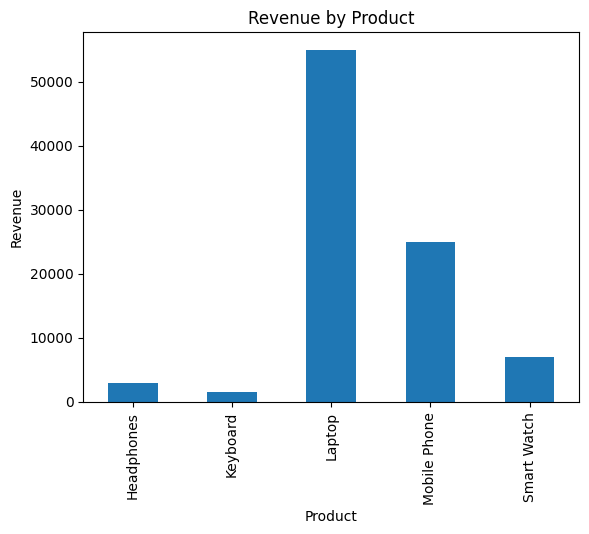

In [56]:
#Analysis

print("Total Revenue:", df["amount"].sum())

print("Average Invoice Value:", df["amount"].mean())

highest = df.loc[df["amount"].idxmax()]

print(highest)

product_revenue = df.groupby("product")["amount"].sum()

print(product_revenue)

product_revenue.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()